In [1]:
import os
os.chdir('/Users/arjunshah/Documents/GitHub/deribit_market_model')

from data_adapters.deribit_adapters import read_parquet, read_clean_jsonl  # -> [`data_adapters.deribit_adapters.read_parquet`](data_adapters/deribit_adapters.py)
from config import Algo1Config, DecoderKind               # -> [`config.Algo1Config`](config.py), [`config.DecoderKind`](config.py)
from pipeline.algo1_PCA import run_algo1_deribit  

/var/folders/mp/_m7_15bd59q6ry66dn_mvmvh0000gn/T/ipykernel_1986/4102030307.py:21: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(CSV)
/Users/arjunshah/Documents/GitHub/deribit_market_model/data_adapters/deribit_adapters.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['expiry'] = pd.to_datetime(df['expiry'])


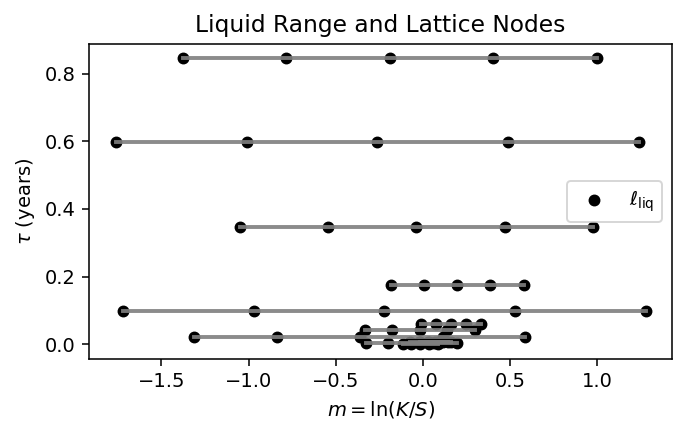

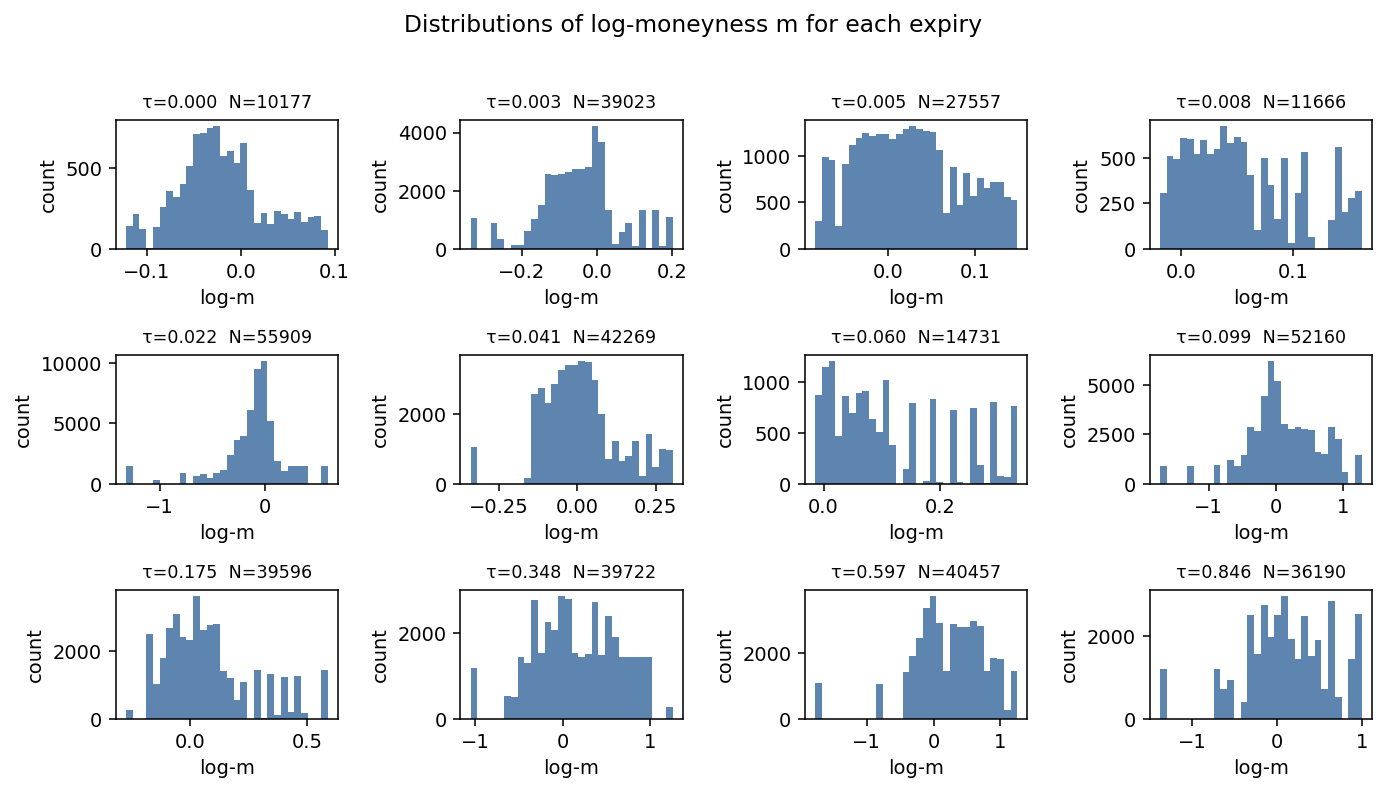

In [3]:
# Make this repo importable even if the notebook was started elsewhere
import sys, subprocess
try:
    ROOT = subprocess.check_output(["git","rev-parse","--show-toplevel"], text=True).strip()
except Exception:
    ROOT = "/Users/arjunshah/Documents/GitHub/deribit_market_model"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import Algo1Config                           # -> config.Algo1Config
from data_adapters.deribit_adapters import clean_deribit # -> data_adapters.deribit_adapters.clean_deribit
from lattice.grid import build_lattice_grid              # -> lattice.grid.build_lattice_grid

# ------------------ load & clean ------------------
# Raw file included in this repo
CSV = f"{ROOT}/data/deribit_options_2025-05-22.csv"
df_raw = pd.read_csv(CSV)

# Clean with default microstructure filters
cfg = Algo1Config()
df = clean_deribit(df_raw, reference_date="2025-05-22", r=0.0, q=0.0, micro=None).sort_values("timestamp")

# Ensure required columns exist
assert {"tau","m"}.issubset(df.columns), "Expected columns tau and m after cleaning."

# ------------------ build lattice (τ,m) ------------------
# Use more τ bins for the histogram panel (e.g., 12×)
n_tau, n_m = 12, 12
lat = build_lattice_grid(df, n_tau=5, n_m=5)  # tau_grid + per‑τ m_grid from P1/P99

tau_grid = lat.tau_grid.astype(float)
nodes    = lat.nodes.astype(float)         # (N, 2) cartesian product of tau_grid × m_grid[τ]

# Assign each quote to nearest τ-grid (for per‑expiry stats/plots)
# Vectorized nearest grid index
tau_vals = df["tau"].to_numpy()
idx_tau  = np.abs(tau_vals[:,None] - tau_grid[None,:]).argmin(axis=1)
df = df.assign(tau_bucket=tau_grid[idx_tau])

# Compute liquid m-range per τ from empirical percentiles (P1/P99 as in builder)
p_lo, p_hi = 1, 99
m_ranges = (
    df.groupby("tau_bucket")["m"]
      .agg(lo=lambda s: np.percentile(s, p_lo),
           hi=lambda s: np.percentile(s, p_hi))
      .reindex(tau_grid, fill_value=np.nan)
)

# ------------------ Figure 1: Liquid range + lattice nodes ------------------
fig, ax = plt.subplots(figsize=(5.0, 3.2), dpi=140)

# Draw horizontal segments for [m_lo, m_hi] at each τ
for τ, row in m_ranges.dropna().iterrows():
    ax.plot([row["lo"], row["hi"]], [τ, τ], color="#7f7f7f", lw=2.0, alpha=0.9)

# Overlay the discovered lattice nodes ℓ_liq
ax.scatter(nodes[:,1], nodes[:,0], s=26, c="k", label=r"$\ell_{\mathrm{liq}}$")

ax.set_title("Liquid Range and Lattice Nodes")
ax.set_xlabel(r"$m = \ln(K/S)$")
ax.set_ylabel(r"$\tau$ (years)")
ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

# ------------------ Figure 2: Distributions of log‑moneyness per expiry ------------------
# Build grids of histograms (one per τ bucket)
m_by_tau = [df.loc[df["tau_bucket"]==τ, "m"].to_numpy() for τ in tau_grid]
n = len(tau_grid)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5.5), dpi=140, sharex=False, sharey=False)
axes = np.asarray(axes).ravel()

for i, τ in enumerate(tau_grid):
    ax = axes[i]
    mvals = m_by_tau[i]
    if mvals.size > 0:
        ax.hist(mvals, bins=30, color="#4c78a8", alpha=0.9, edgecolor="none")
    ax.set_title(f"τ={τ:.3f}  N={mvals.size}", fontsize=9)
    ax.set_xlabel("log-m")
    ax.set_ylabel("count")

# hide any unused axes
for j in range(i+1, nrows*ncols):
    axes[j].axis("off")

fig.suptitle("Distributions of log‑moneyness m for each expiry", y=1.02)
plt.tight_layout()
plt.show()

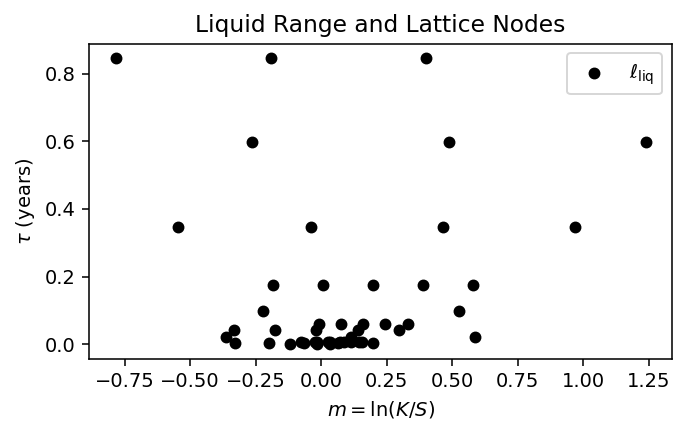

In [4]:
# Load and plot the liquid nodes exactly as in your screenshot
import sys, subprocess, joblib, numpy as np, matplotlib.pyplot as plt

# Ensure this repo is importable for unpickling (pipeline.* classes)
try:
    ROOT = subprocess.check_output(["git","rev-parse","--show-toplevel"], text=True).strip()
except Exception:
    ROOT = "/Users/arjunshah/Documents/GitHub/deribit_market_model"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Make sure the 'pipeline' module is importable for unpickling
sys.modules.pop("pipeline", None)
sys.modules.pop("pipeline.algo1_PCA", None)
import pipeline.algo1_PCA  # noqa: F401

# Load the saved outputs
pkl = f"{ROOT}/outputs/artifacts/algo1_outs_2025-05-22_1min_agreg.pkl"
outs = joblib.load(pkl)

# Pick the first available nodes attribute safely (avoid 'or' on arrays)
nodes = None
used_attr = None
for attr in ("nodes_sub", "nodes_liq", "nodes"):
    arr = getattr(outs, attr, None)
    if arr is not None:
        nodes = np.asarray(arr, dtype=float)
        used_attr = attr
        break

assert nodes is not None, "No nodes attribute found on outs (tried nodes_sub, nodes_liq, nodes)."

# Ensure shape is (K,2) as (tau, m); transpose if stored as (2,K)
if nodes.ndim != 2:
    raise ValueError(f"Unexpected nodes ndim={nodes.ndim}, expected 2.")
if nodes.shape[1] != 2 and nodes.shape[0] == 2:
    nodes = nodes.T
assert nodes.shape[1] == 2, f"Expected nodes shape (K,2), got {nodes.shape} from {used_attr}."

# Plot exactly the points (no extra τ bins or ranges)
fig, ax = plt.subplots(figsize=(5.0, 3.2), dpi=140)
ax.scatter(nodes[:, 1], nodes[:, 0], s=26, c="black", label=r"$\ell_{\mathrm{liq}}$")
ax.set_title("Liquid Range and Lattice Nodes")
ax.set_xlabel(r"$m = \ln(K/S)$")
ax.set_ylabel(r"$\tau$ (years)")
ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()